In [1]:
import torch
print(torch.__version__)

2.10.0+cu126


In [2]:
import matplotlib.pyplot as plt
import numpy as np


In [3]:
X = np.arange(0,1,0.02)
print(X[:3])
y = 0.66778*X + 0.98761
print(y[:3])
print(len(X),len(y))

[0.   0.02 0.04]
[0.98761   1.0009656 1.0143212]
50 50


In [4]:
split = int(len(X)*0.8)
X_train, y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]
print(f"Length of X_train = {len(X_train)} & length of y_train = {len(y_train)}")
print(f"Length of X_test = {len(X_test)} & length of y_test = {len(y_test)}")


Length of X_train = 40 & length of y_train = 40
Length of X_test = 10 & length of y_test = 10


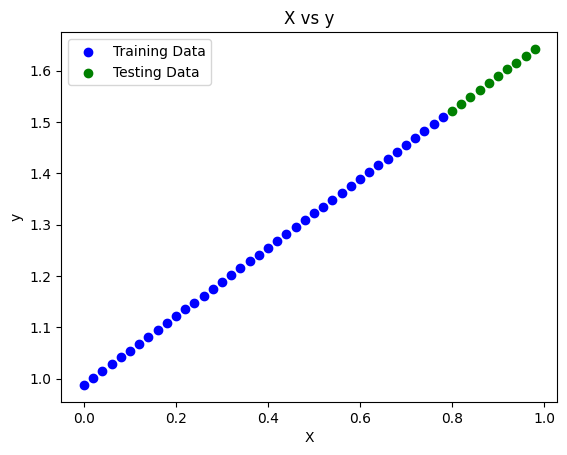

In [5]:
def plot_data(X_train = X_train, y_train = y_train,
              X_test = X_test, y_test = y_test,
              predictions = None):
    plt.scatter(X_train, y_train, c='b', label='Training Data')
    plt.scatter(X_test, y_test, c='g', label='Testing Data')
    if predictions is not None:
        plt.plot(X_test, predictions, c="r", label="Predicted Data")
    plt.title("X vs y")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.legend()
    plt.show()
plot_data() 

In [6]:
# Initialize weights an bias
weight = np.random.randn()
bias = np.random.randn()
print(f"Initial weight = {weight} & Initial bias = {bias}")


Initial weight = 0.45723284771700584 & Initial bias = -1.085108335972636


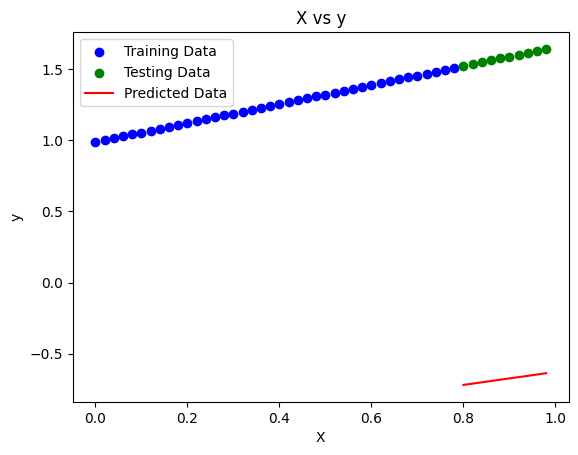

In [7]:
y_pred = X_test * weight + bias
plot_data(predictions = y_pred)

In [8]:
def loss_fun(y_true, y_pred):
    return np.sum(np.square(y_true - y_pred))/len(y_true)

In [9]:
alpha = 0.1 
epochs = 500
train_loss_list = []
test_loss_list =[]
for epoch in range(epochs):
    # Training data
    # Forward Pass
    train_pred = weight * X_train + bias
    train_loss = loss_fun(y_true=y_train, y_pred = train_pred)
    
    # Compute the gradients
    gradientW = -2/len(X_train) * np.sum((y_train - train_pred)* X_train)
    gradientb = -2/len(X_train) * np.sum(y_train - train_pred)
    
    # Back Pass - Backpropagate
    weight = weight - alpha*gradientW
    bias = bias - alpha*gradientb
    
    # Test data
    test_pred = weight * X_test + bias
    test_loss = loss_fun(y_true = y_test, y_pred = test_pred)
    
    train_loss_list.append(train_loss)
    test_loss_list.append(test_loss)
    
    if (epoch + 1)%10 == 0:
        print(f"Epoch {epoch + 1}| Train loss {train_loss: 4f} Test loss {test_loss: 4f}")

Epoch 10| Train loss  0.053631 Test loss  0.004133
Epoch 20| Train loss  0.011448 Test loss  0.042842
Epoch 30| Train loss  0.009348 Test loss  0.039799
Epoch 40| Train loss  0.007770 Test loss  0.033367
Epoch 50| Train loss  0.006460 Test loss  0.027757
Epoch 60| Train loss  0.005370 Test loss  0.023076
Epoch 70| Train loss  0.004464 Test loss  0.019184
Epoch 80| Train loss  0.003711 Test loss  0.015948
Epoch 90| Train loss  0.003085 Test loss  0.013258
Epoch 100| Train loss  0.002565 Test loss  0.011022
Epoch 110| Train loss  0.002132 Test loss  0.009163
Epoch 120| Train loss  0.001773 Test loss  0.007617
Epoch 130| Train loss  0.001474 Test loss  0.006332
Epoch 140| Train loss  0.001225 Test loss  0.005264
Epoch 150| Train loss  0.001018 Test loss  0.004376
Epoch 160| Train loss  0.000847 Test loss  0.003638
Epoch 170| Train loss  0.000704 Test loss  0.003024
Epoch 180| Train loss  0.000585 Test loss  0.002514
Epoch 190| Train loss  0.000486 Test loss  0.002090
Epoch 200| Train loss

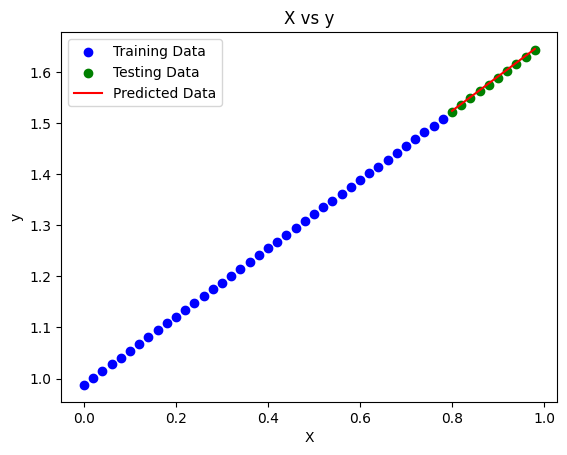

In [10]:
y_pred = X_test * weight + bias
plot_data(predictions=y_pred)


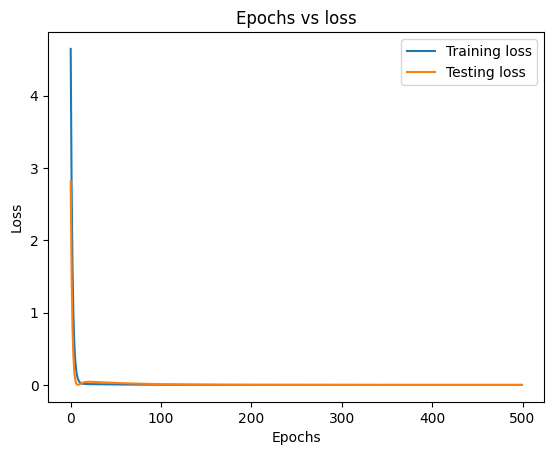

In [11]:
# plot loss curve
plt.plot(range(epochs), train_loss_list, label = "Training loss")
plt.plot(range(epochs), test_loss_list, label = "Testing loss")
plt.title("Epochs vs loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [12]:
print(f"Final Weight = {weight} & Final Bias = {bias}")

Final Weight = 0.6731644472795315 & Final Bias = 0.9854088780000813
